# Amazon Sales Dataset— Exploratory Data Analysis

This notebook performs full EDA on the Amazon product dataset, covering:
- Data loading & cleaning
- Univariate and multivariate analysis
- Category breakdowns
- Price & discount analysis
- Rating distributions
- Review insights
- Top products

---

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

df = pd.read_csv('amazon.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


## 2. Data Cleaning & Feature Engineering

In [ ]:
def clean_price(col):
    return pd.to_numeric(
        col.astype(str).str.replace('[₹,]', '', regex=True).str.strip(),
        errors='coerce'
    )

df['discounted_price'] = clean_price(df['discounted_price'])
df['actual_price']     = clean_price(df['actual_price'])

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df['discount_pct'] = pd.to_numeric(
    df['discount_percentage'].astype(str).str.replace('%', '').str.strip(),
    errors='coerce'
)

df['rating_count_clean'] = pd.to_numeric(
    df['rating_count'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)

df['main_category'] = df['category'].str.split('|').str[0]
df['sub_category']  = df['category'].str.split('|').str[1]

df.dropna(subset=['actual_price', 'discounted_price', 'rating'], inplace=True)

df['savings'] = df['actual_price'] - df['discounted_price']

df['value_score'] = df['rating'] * np.log1p(df['rating_count_clean'].fillna(0))

print(f'Clean dataset shape: {df.shape}')
df[['product_name','main_category','actual_price','discounted_price','discount_pct','rating','rating_count_clean']].head(5)

Clean dataset shape: (1464, 22)


,product_name,main_category,actual_price,discounted_price,discount_pct,rating,rating_count_clean
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,1099.0,399.0,64,4.2,24269.0
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories,349.0,199.0,43,4.0,43994.0
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories,1899.0,199.0,90,3.9,7928.0
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories,699.0,329.0,53,4.2,94363.0
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories,399.0,154.0,61,4.2,16905.0


In [ ]:
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0]

if missing_nonzero.empty:
    print('No missing values found after cleaning ✅')
else:
    print(f'Columns with missing values ({len(missing_nonzero)} found):')
    print(missing_nonzero.to_string())

Columns with missing values (2 found):
rating_count          2
rating_count_clean    2


## 3. Descriptive Statistics

In [4]:
stats_cols = ['actual_price', 'discounted_price', 'discount_pct', 'rating', 'rating_count_clean', 'savings']
df[stats_cols].describe().round(2)

,actual_price,discounted_price,discount_pct,rating,rating_count_clean,savings
count,1464.00,1464.00,1464.00,1464.00,1462.00,1464.00
mean,5447.00,3126.01,47.71,4.10,18307.38,2320.99
std,10878.27,6946.63,21.63,0.29,42766.10,4605.77
min,39.00,39.00,0.00,2.00,2.00,0.00
25%,800.00,323.75,32.00,4.00,1191.50,370.75
50%,1650.00,799.00,50.00,4.10,5179.00,800.00
75%,4303.75,1999.00,63.00,4.30,17342.25,1955.00
max,139900.00,77990.00,94.00,5.00,426973.00,61910.00


## 4. Category Distribution

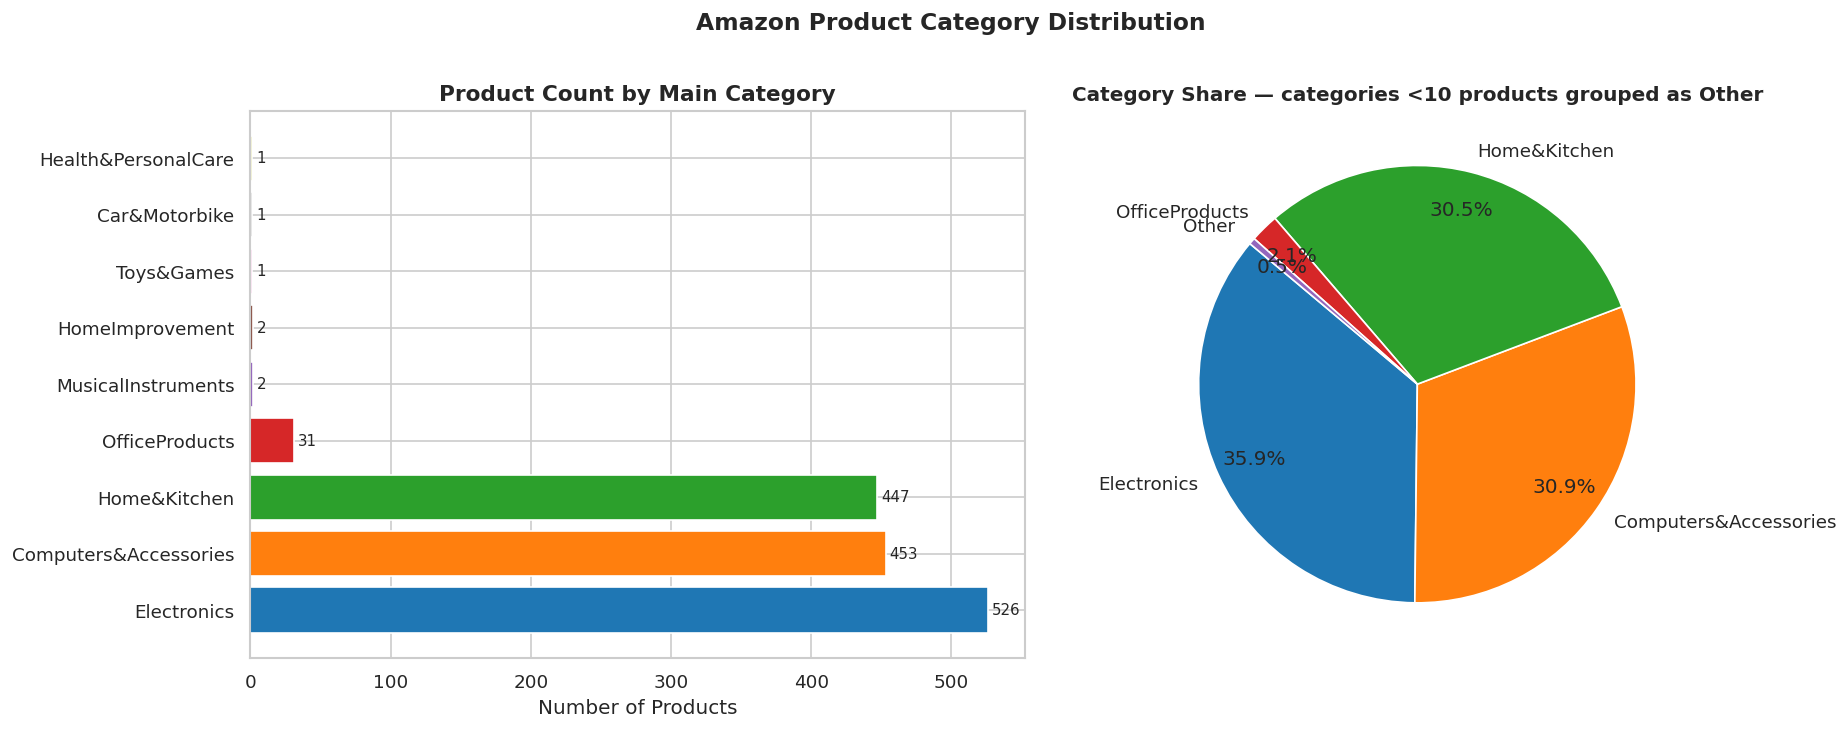

In [ ]:
main_cat_counts = df['main_category'].value_counts()
threshold = 10
large     = main_cat_counts[main_cat_counts >= threshold]
small_sum = main_cat_counts[main_cat_counts < threshold].sum()
grouped_counts = pd.concat([large, pd.Series({'Other': small_sum})]) if small_sum > 0 else large

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — all categories
colors_bar = sns.color_palette('tab10', len(main_cat_counts))
axes[0].barh(main_cat_counts.index, main_cat_counts.values, color=colors_bar)
axes[0].set_title('Product Count by Main Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Products')
for i, v in enumerate(main_cat_counts.values):
    axes[0].text(v + 3, i, str(v), va='center', fontsize=9)

# Pie chart — small categories grouped as 'Other'
pie_colors = sns.color_palette('tab10', len(grouped_counts))
axes[1].pie(
    grouped_counts.values,
    labels=[c[:22] for c in grouped_counts.index],
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    pctdistance=0.82
)
axes[1].set_title('Category Share — categories <10 products grouped as Other', fontsize=12, fontweight='bold')

plt.suptitle('Amazon Product Category Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

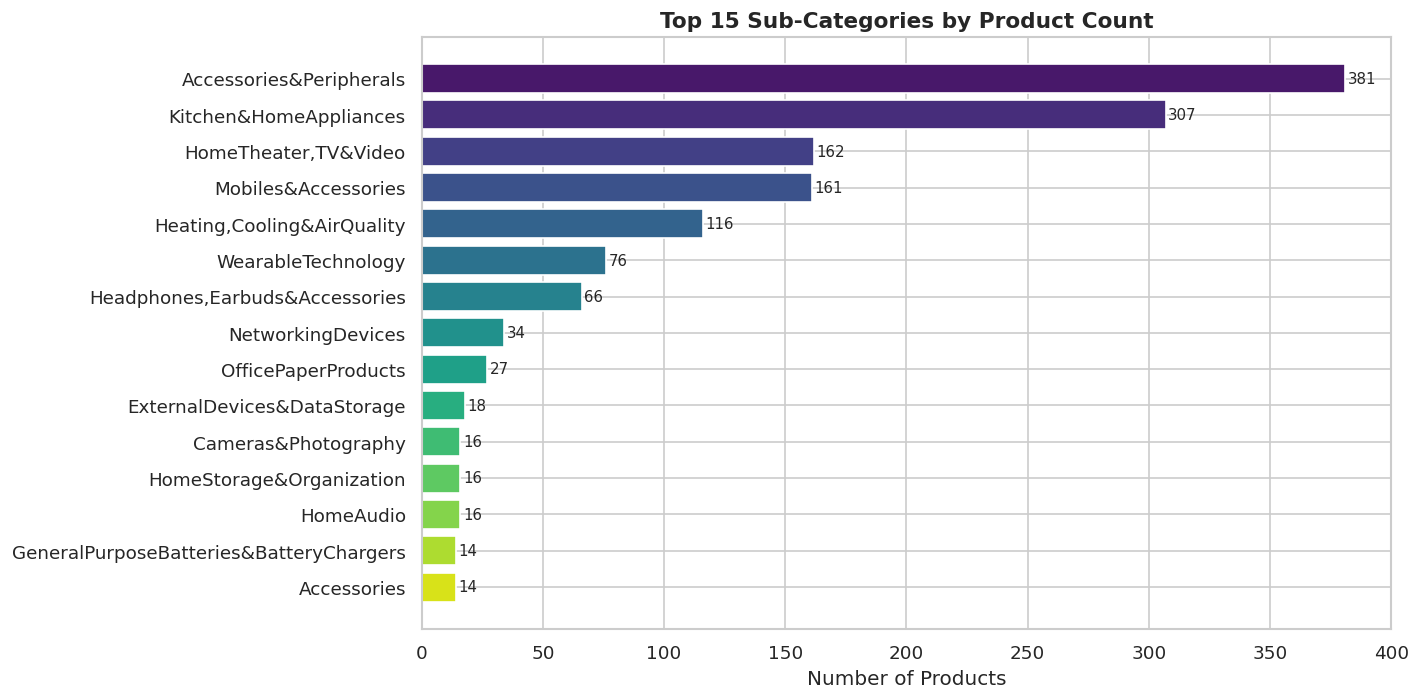

In [6]:
# Top 15 sub-categories
top_sub = df['sub_category'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(top_sub))
bars = ax.barh(top_sub.index[::-1], top_sub.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Sub-Categories by Product Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Products')
for bar, val in zip(bars, top_sub.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Price Analysis

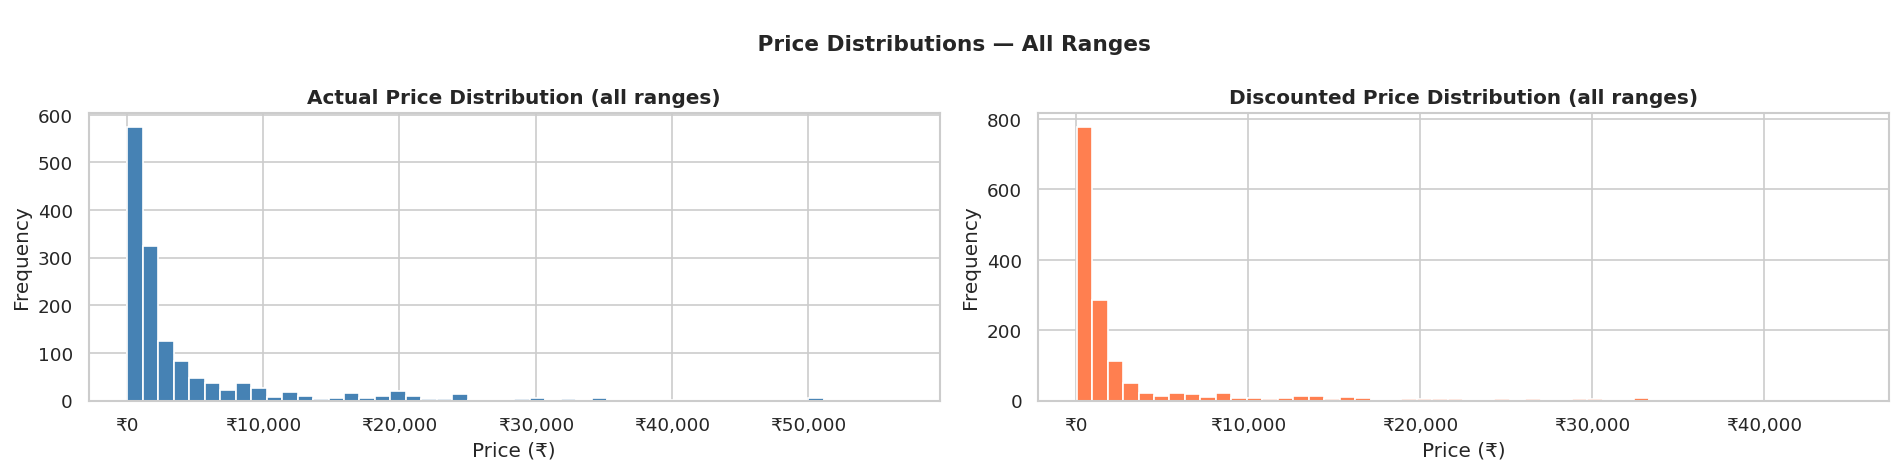


 Products with price < ₹3,000: 998  (68.2% of dataset)



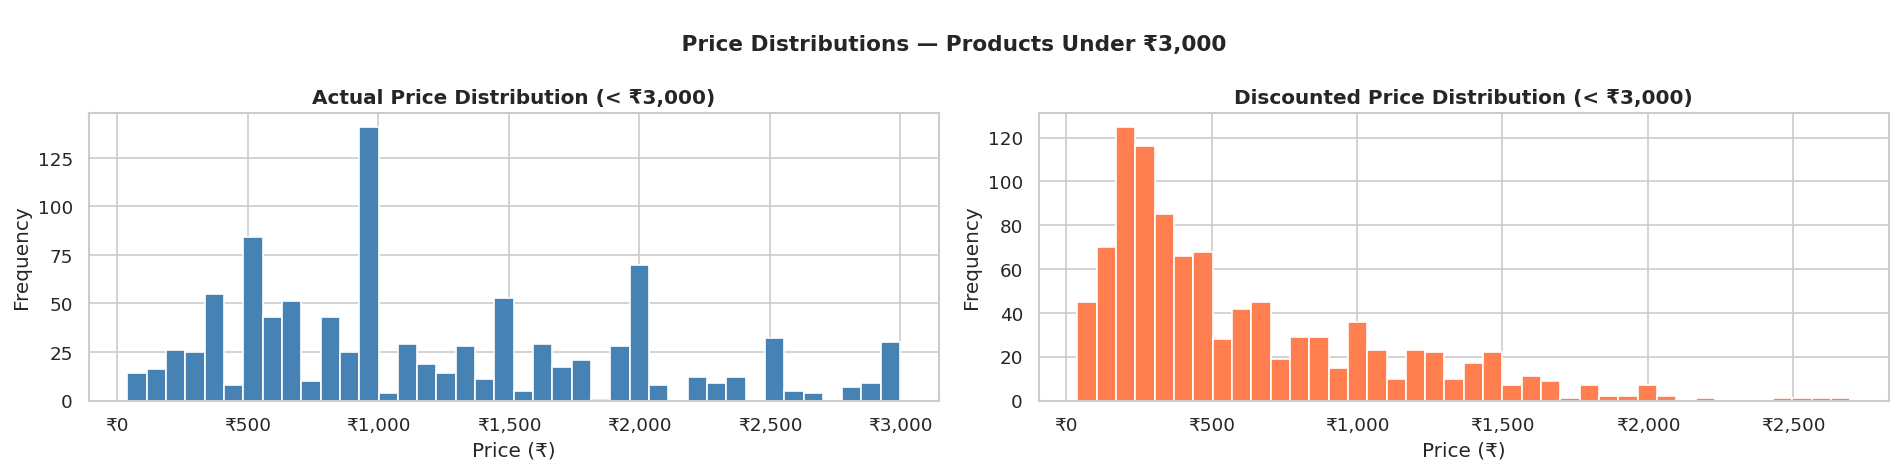

In [ ]:
cap = df['actual_price'].quantile(0.99)
price_all = df[df['actual_price'] <= cap]

# All price ranges 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(price_all['actual_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Actual Price Distribution (all ranges)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[1].hist(price_all['discounted_price'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Discounted Price Distribution (all ranges)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.suptitle('\n Price Distributions — All Ranges', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Products with price < ₹3,000  
price_sub3k = df[(df['actual_price'] < 3000) & (df['discounted_price'] < 3000)]
print(f'\n Products with price < ₹3,000: {len(price_sub3k):,}  ({100*len(price_sub3k)/len(df):.1f}% of dataset)\n')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(price_sub3k['actual_price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Actual Price Distribution (< ₹3,000)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[1].hist(price_sub3k['discounted_price'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Discounted Price Distribution (< ₹3,000)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.suptitle('\n Price Distributions — Products Under ₹3,000', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

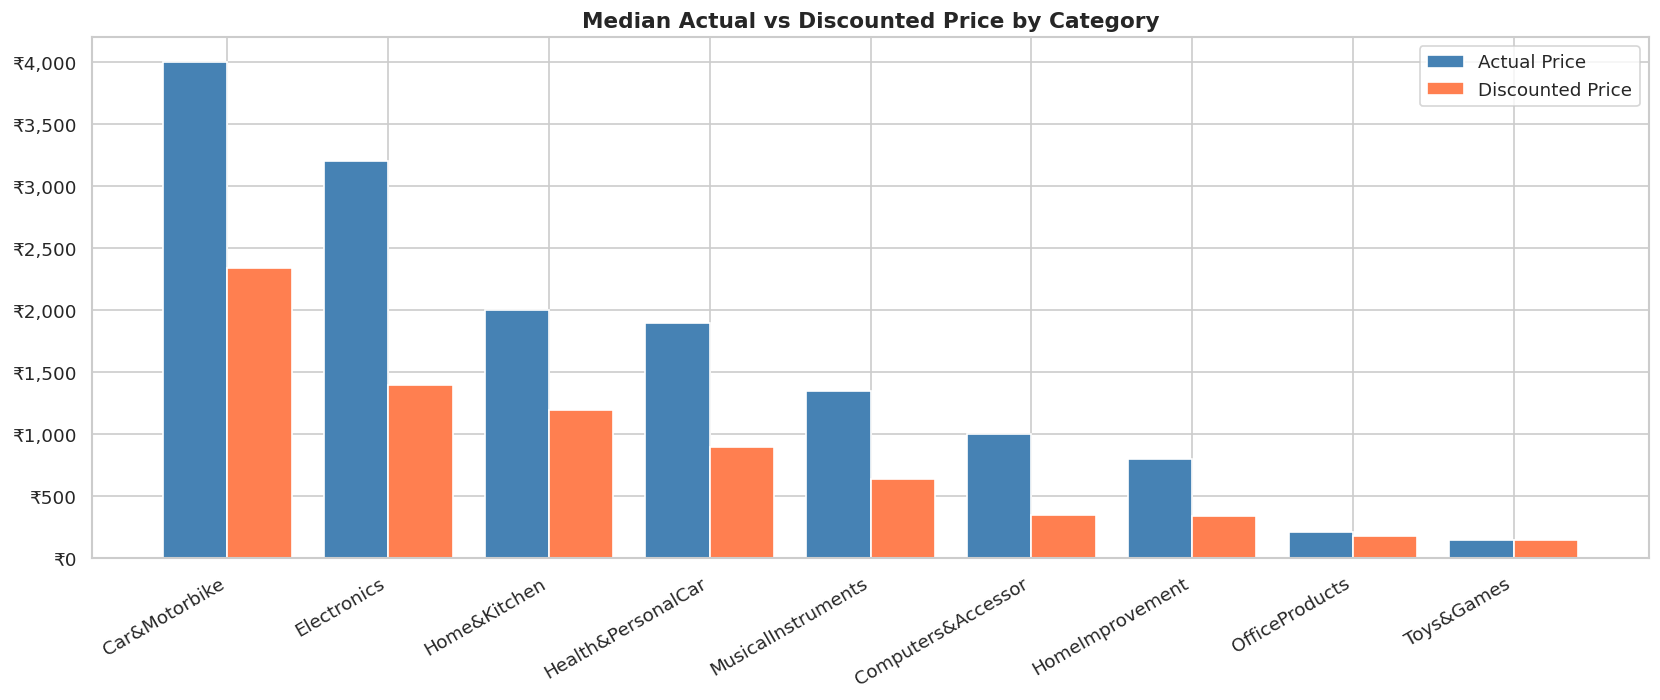

In [ ]:
# Avg actual price vs avg discounted price by category
cat_price = df.groupby('main_category')[['actual_price', 'discounted_price']].median().sort_values('actual_price', ascending=False)

x = np.arange(len(cat_price))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, cat_price['actual_price'], width, label='Actual Price', color='steelblue')
ax.bar(x + width/2, cat_price['discounted_price'], width, label='Discounted Price', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([c[:18] for c in cat_price.index], rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'₹{y:,.0f}'))
ax.set_title('Median Actual vs Discounted Price by Category', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

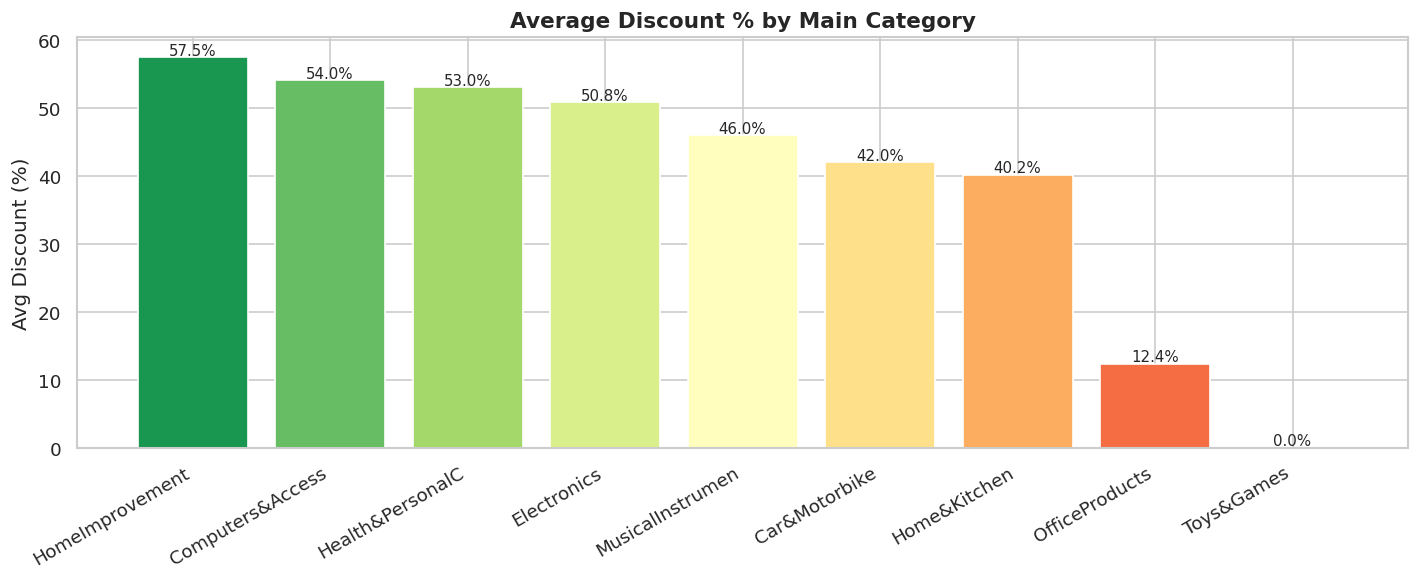

In [ ]:
# Average discount % by category — sorted
cat_disc = df.groupby('main_category')['discount_pct'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('RdYlGn_r', len(cat_disc))
bars = ax.bar(cat_disc.index, cat_disc.values, color=palette, edgecolor='white')
ax.set_xticklabels([c[:16] for c in cat_disc.index], rotation=30, ha='right')
ax.set_title('Average Discount % by Main Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Discount (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

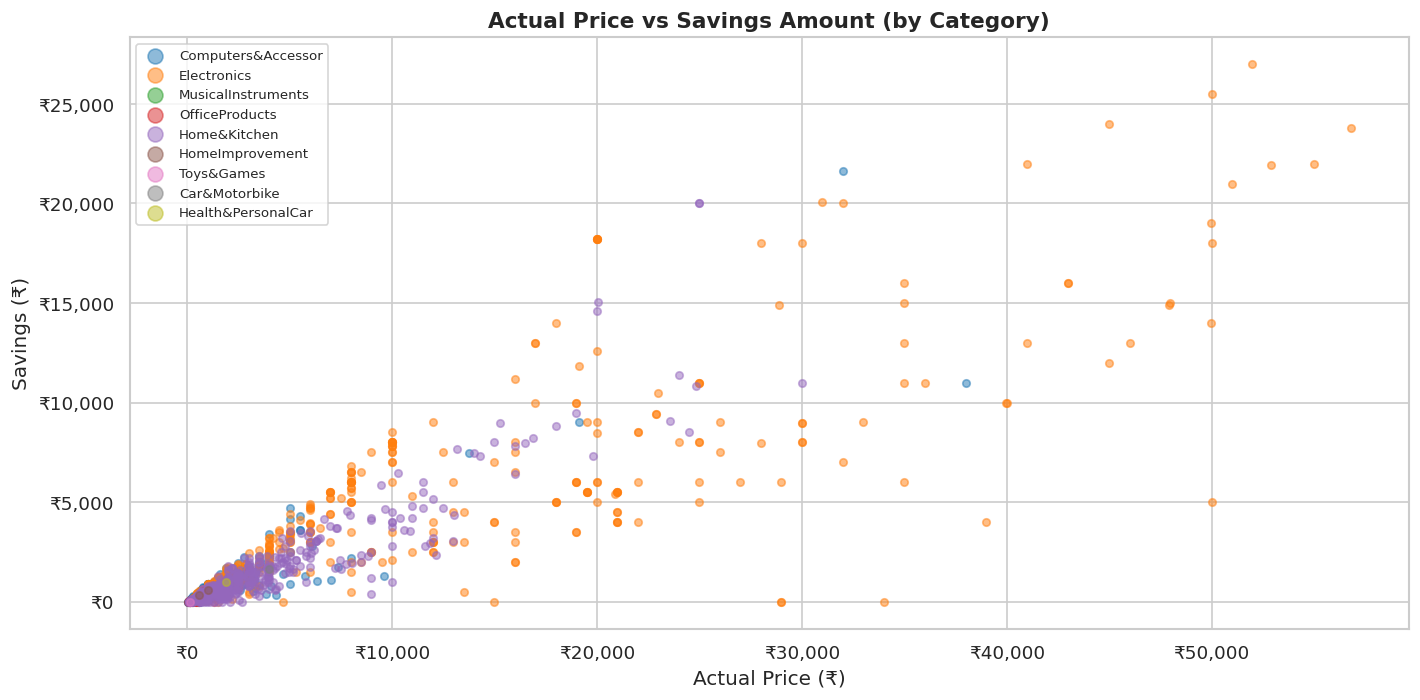

In [ ]:
# Scatterplot: actual price vs savings
fig, ax = plt.subplots(figsize=(12, 6))
categories = df['main_category'].unique()
palette = sns.color_palette('tab10', len(categories))
for cat, col in zip(categories, palette):
    sub = df[(df['main_category'] == cat) & (df['actual_price'] <= cap)]
    ax.scatter(sub['actual_price'], sub['savings'], label=cat[:18], alpha=0.5, s=20, color=col)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'₹{y:,.0f}'))
ax.set_title('Actual Price vs Savings Amount (by Category)', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Price (₹)')
ax.set_ylabel('Savings (₹)')
ax.legend(fontsize=8, loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

## 6. Rating Analysis

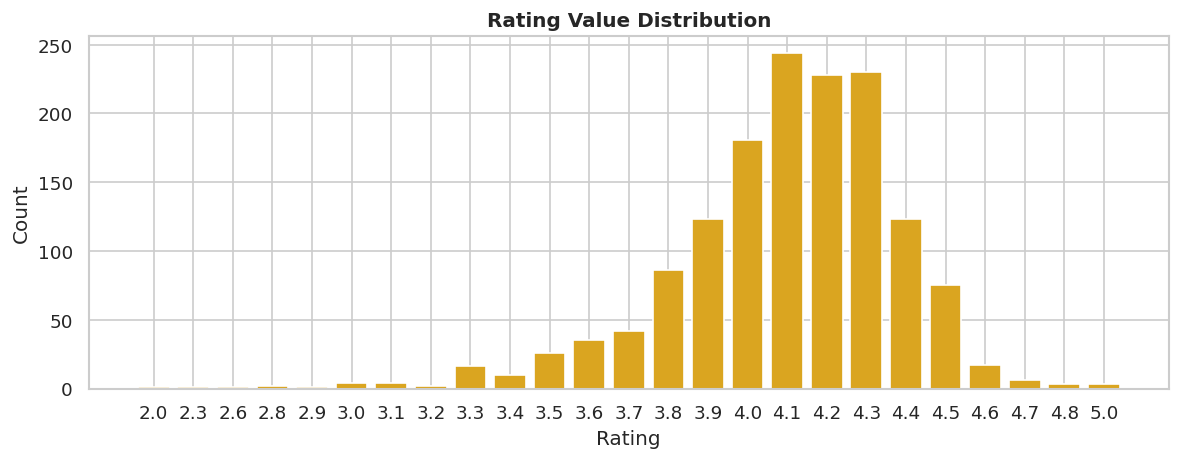

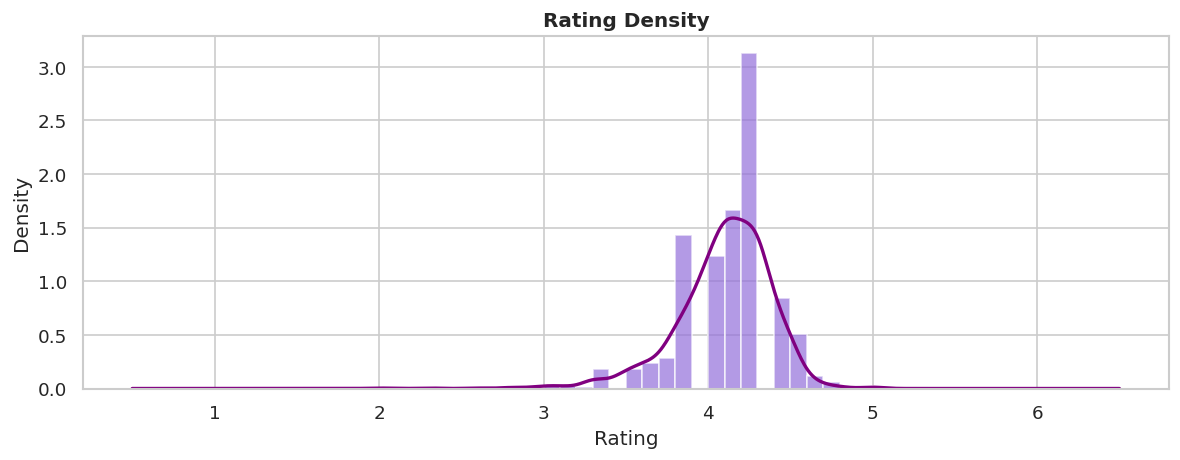

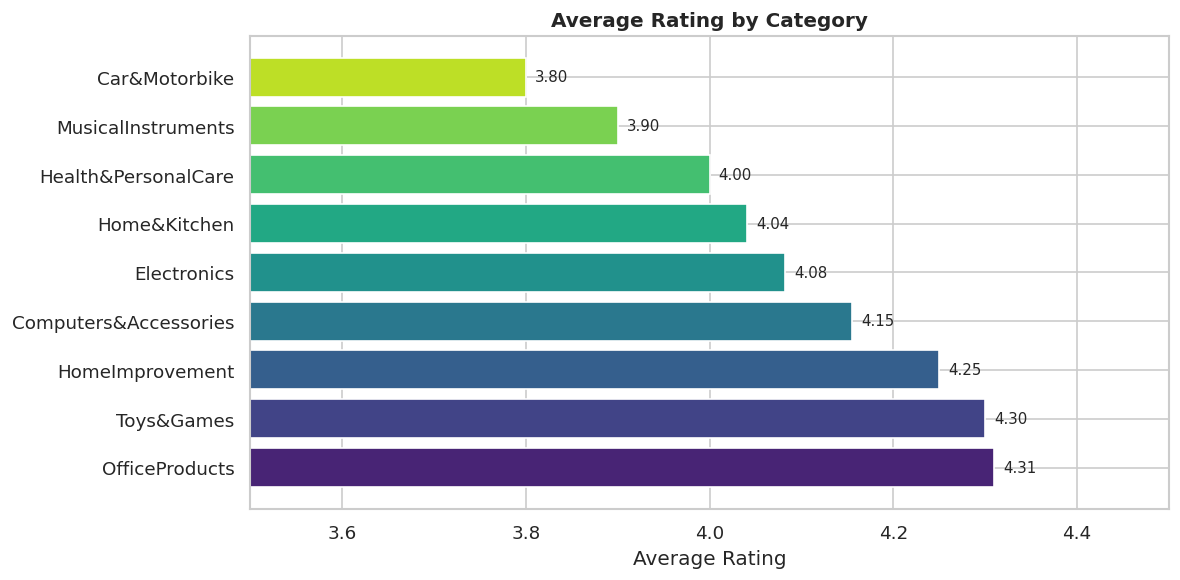

In [ ]:
# Rating value distribution
rating_counts = df["rating"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(rating_counts.index.astype(str), rating_counts.values, color="goldenrod", edgecolor="white")
ax.set_title("Rating Value Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Rating density with KDE
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["rating"], bins=30, color="mediumpurple", edgecolor="white", density=True, alpha=0.7)
df["rating"].plot.kde(ax=ax, color="purple", lw=2)
ax.set_title("Rating Density", fontsize=12, fontweight="bold")
ax.set_xlabel("Rating")
plt.tight_layout()
plt.show()

# Avg rating by category
avg_rat = df.groupby("main_category")["rating"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(avg_rat.index, avg_rat.values, color=sns.color_palette("viridis", len(avg_rat)))
ax.set_xlim(3.5, 4.5)
ax.set_title("Average Rating by Category", fontsize=12, fontweight="bold")
ax.set_xlabel("Average Rating")
for i, v in enumerate(avg_rat.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

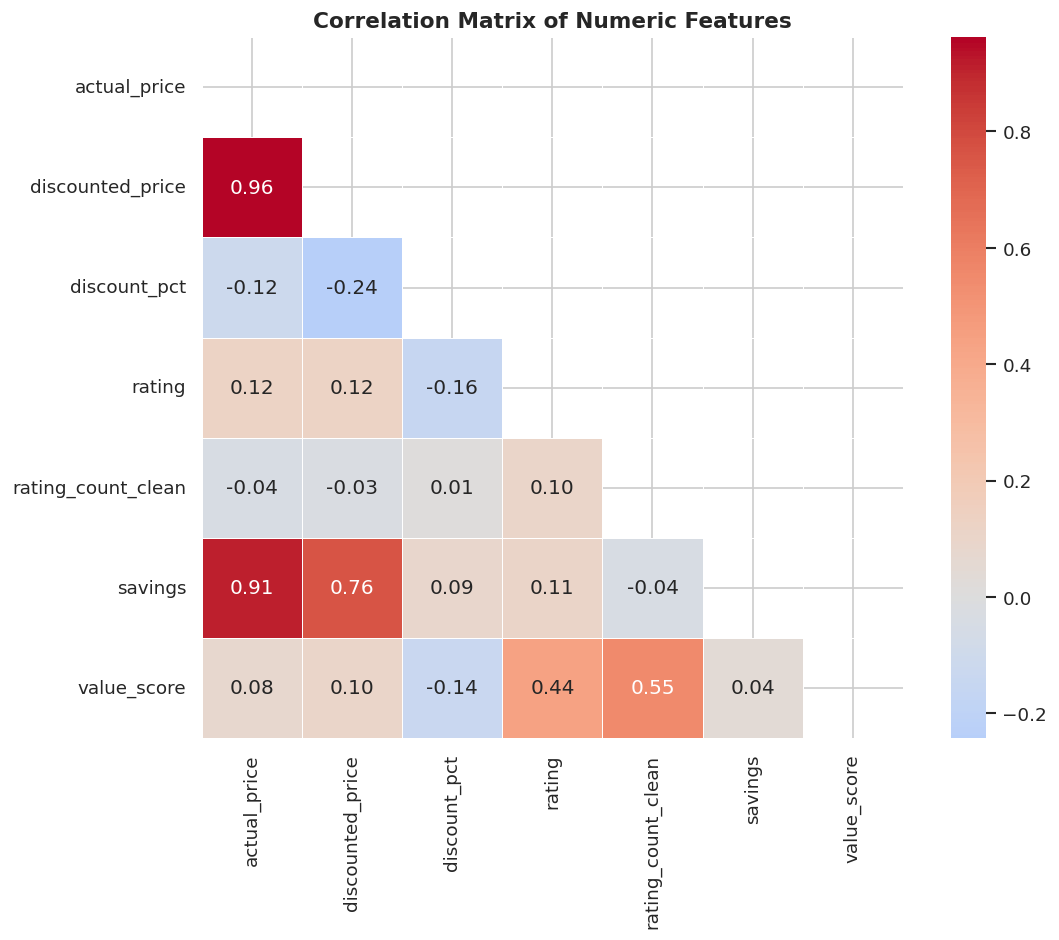

In [ ]:
# Correlation matrix: rating vs discount, price, rating_count
corr_cols = ['actual_price', 'discounted_price', 'discount_pct', 'rating', 'rating_count_clean', 'savings', 'value_score']
corr_df = df[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(
    corr_df.corr(), mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

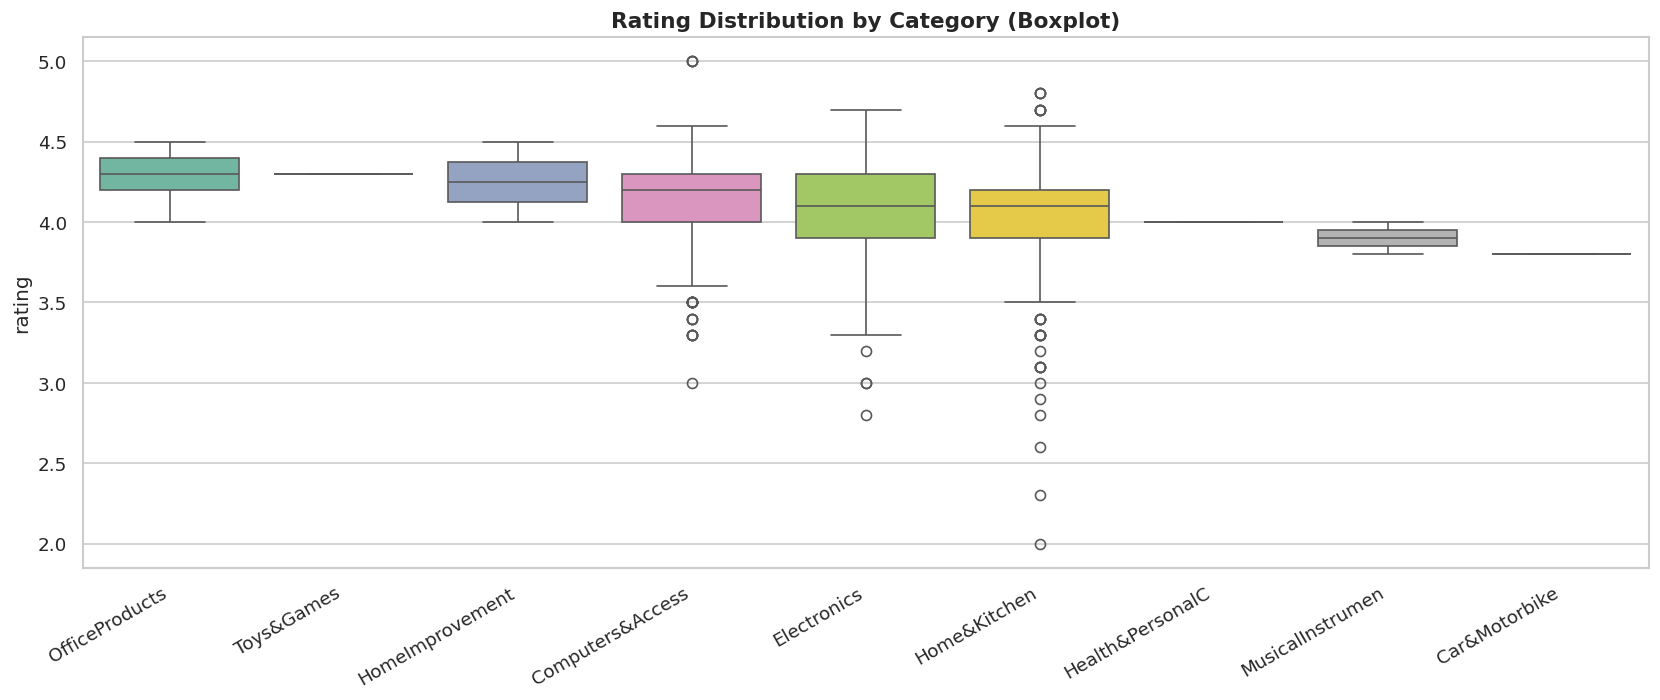

In [13]:
# Box plot: rating by main category
fig, ax = plt.subplots(figsize=(14, 6))
order = df.groupby('main_category')['rating'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='main_category', y='rating', order=order,
            palette='Set2', ax=ax)
ax.set_xticklabels([c[:16] for c in order], rotation=30, ha='right')
ax.set_title('Rating Distribution by Category (Boxplot)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

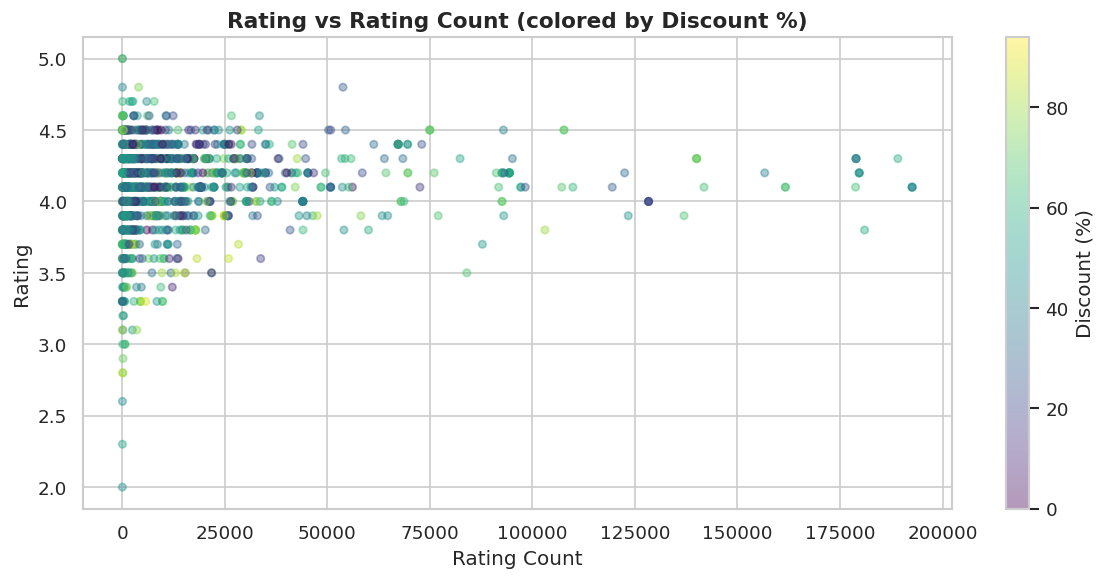

In [ ]:
# Scatterplot: rating vs rating_count
fig, ax = plt.subplots(figsize=(10, 5))
rc_cap = df['rating_count_clean'].quantile(0.99)
sub = df[df['rating_count_clean'] <= rc_cap].dropna(subset=['rating_count_clean'])
scatter = ax.scatter(sub['rating_count_clean'], sub['rating'],
                     alpha=0.4, c=sub['discount_pct'], cmap='viridis', s=20)
plt.colorbar(scatter, ax=ax, label='Discount (%)')
ax.set_title('Rating vs Rating Count (colored by Discount %)', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating Count')
ax.set_ylabel('Rating')
plt.tight_layout()
plt.show()

## 7. Discount Deep Dive

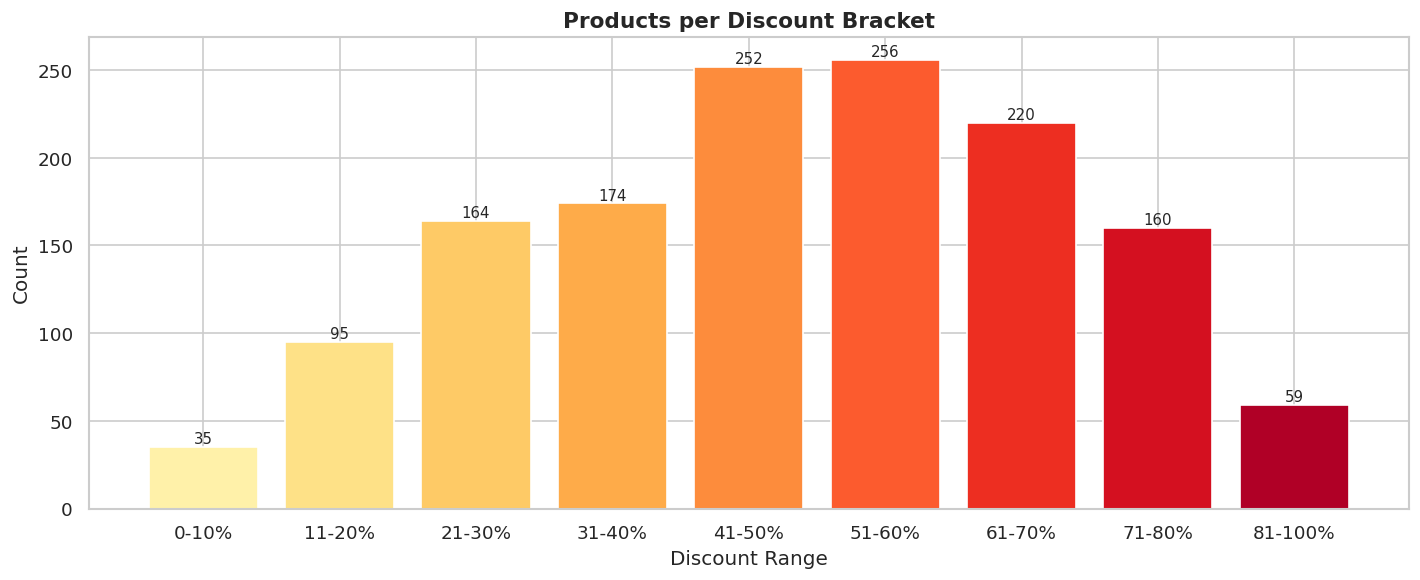

In [ ]:
# Count of products per discount range
bins   = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ['0-10%','11-20%','21-30%','31-40%','41-50%','51-60%','61-70%','71-80%','81-100%']
df['disc_bracket'] = pd.cut(df['discount_pct'].dropna(), bins=bins, labels=labels)
bracket_counts = df['disc_bracket'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(bracket_counts.index, bracket_counts.values,
       color=sns.color_palette('YlOrRd', len(bracket_counts)), edgecolor='white')
ax.set_title('Products per Discount Bracket', fontsize=13, fontweight='bold')
ax.set_xlabel('Discount Range')
ax.set_ylabel('Count')
for i, v in enumerate(bracket_counts.values):
    ax.text(i, v + 2, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Top Products

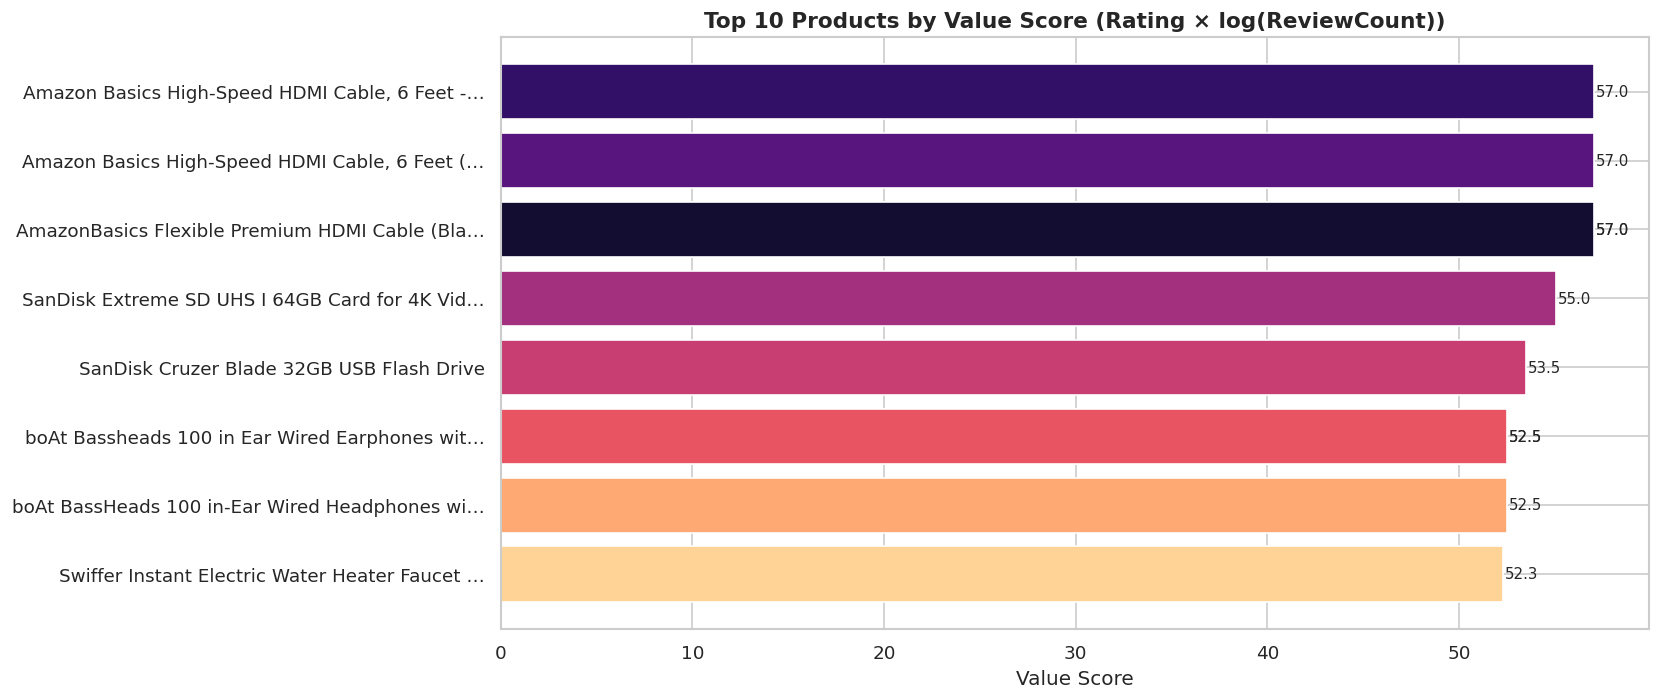


Top 10 Products by Value Score:


,product_name,main_category,rating,rating_count_clean,discounted_price,value_score
0,AmazonBasics Flexible Premium HDMI Cable (Bla…,Electronics,4.4,426973.0,219.0,57.043705
1,"Amazon Basics High-Speed HDMI Cable, 6 Feet -…",Electronics,4.4,426973.0,309.0,57.043705
2,"Amazon Basics High-Speed HDMI Cable, 6 Feet (…",Electronics,4.4,426973.0,309.0,57.043705
3,AmazonBasics Flexible Premium HDMI Cable (Bla…,Electronics,4.4,426972.0,219.0,57.043695
4,SanDisk Extreme SD UHS I 64GB Card for 4K Vid…,Electronics,4.5,205052.0,939.0,55.039607
5,SanDisk Cruzer Blade 32GB USB Flash Drive,Computers&Accessories,4.3,253105.0,289.0,53.498724
6,boAt Bassheads 100 in Ear Wired Earphones wit…,Electronics,4.1,363713.0,349.0,52.496905
7,boAt Bassheads 100 in Ear Wired Earphones wit…,Electronics,4.1,363713.0,379.0,52.496905
8,boAt BassHeads 100 in-Ear Wired Headphones wi…,Electronics,4.1,363711.0,365.0,52.496882
9,Swiffer Instant Electric Water Heater Faucet …,Home&Kitchen,4.8,53803.0,1439.0,52.286895


In [16]:
def truncate(s, n=45):
    return s[:n] + '…' if len(s) > n else s

# Top 10 by value score
top_value = df.nlargest(10, 'value_score')[['product_name', 'main_category', 'rating', 'rating_count_clean', 'discounted_price', 'value_score']].reset_index(drop=True)
top_value['product_name'] = top_value['product_name'].apply(truncate)

fig, ax = plt.subplots(figsize=(14, 6))
colors_top = sns.color_palette('magma', 10)
bars = ax.barh(top_value['product_name'][::-1], top_value['value_score'][::-1], color=colors_top[::-1])
ax.set_title('Top 10 Products by Value Score (Rating × log(ReviewCount))', fontsize=13, fontweight='bold')
ax.set_xlabel('Value Score')
for bar, val in zip(bars, top_value['value_score'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 10 Products by Value Score:')
top_value

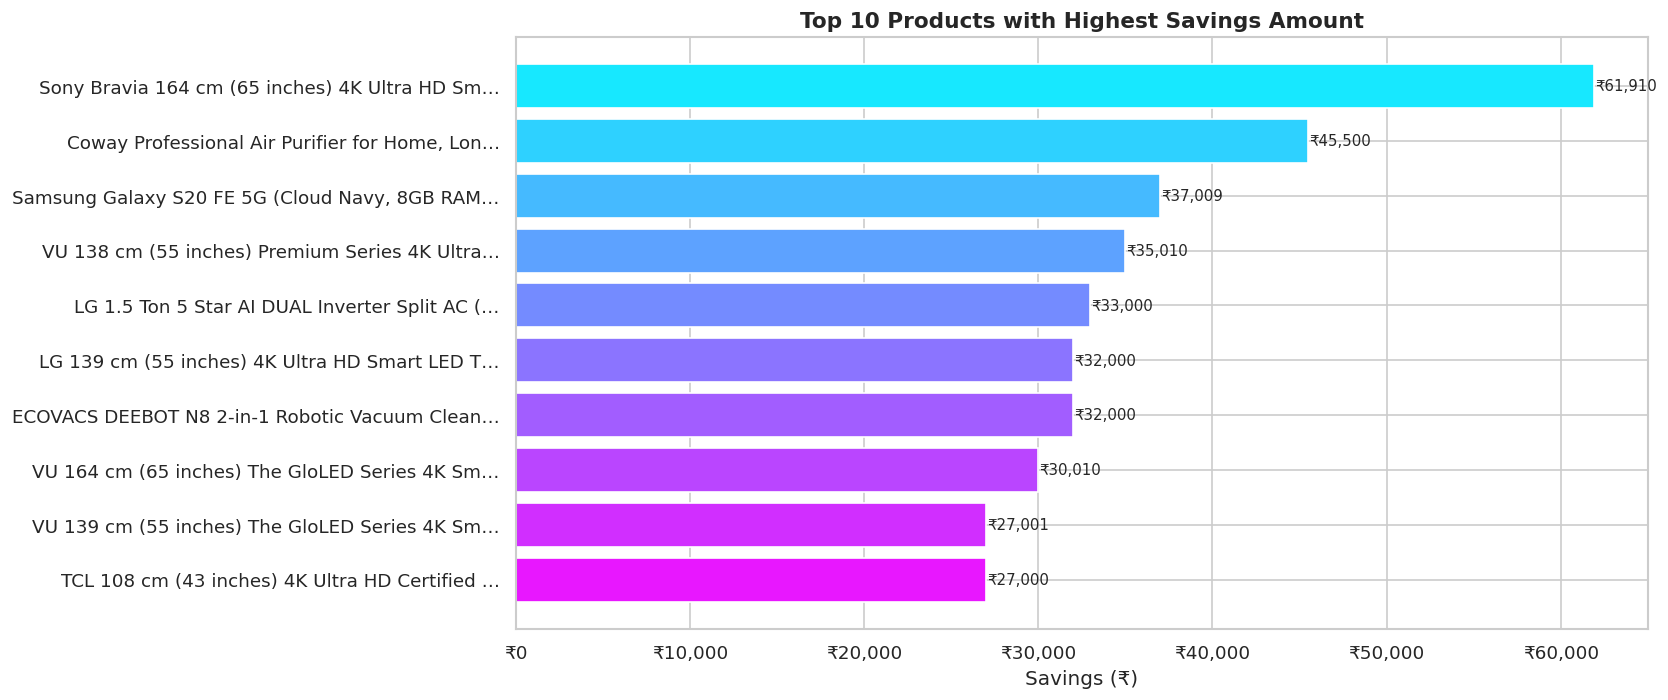


Top 10 Products by Savings Amount:


,product_name,main_category,actual_price,discounted_price,discount_pct,savings
0,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sm…,Electronics,139900.0,77990.0,44,61910.0
1,"Coway Professional Air Purifier for Home, Lon…",Home&Kitchen,59900.0,14400.0,76,45500.0
2,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM…",Electronics,74999.0,37990.0,49,37009.0
3,VU 138 cm (55 inches) Premium Series 4K Ultra…,Electronics,65000.0,29990.0,54,35010.0
4,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (…,Home&Kitchen,75990.0,42990.0,43,33000.0
5,LG 139 cm (55 inches) 4K Ultra HD Smart LED T…,Electronics,79990.0,47990.0,40,32000.0
6,ECOVACS DEEBOT N8 2-in-1 Robotic Vacuum Clean…,Home&Kitchen,59900.0,27900.0,53,32000.0
7,VU 164 cm (65 inches) The GloLED Series 4K Sm…,Electronics,85000.0,54990.0,35,30010.0
8,VU 139 cm (55 inches) The GloLED Series 4K Sm…,Electronics,65000.0,37999.0,42,27001.0
9,TCL 108 cm (43 inches) 4K Ultra HD Certified …,Electronics,51990.0,24990.0,52,27000.0


In [ ]:
# Top 10 products by highest savings
top_savings = df.nlargest(10, 'savings')[['product_name', 'main_category', 'actual_price', 'discounted_price', 'discount_pct', 'savings']].reset_index(drop=True)
top_savings['product_name'] = top_savings['product_name'].apply(truncate)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top_savings['product_name'][::-1], top_savings['savings'][::-1],
               color=sns.color_palette('cool', 10)[::-1])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_title('Top 10 Products with Highest Savings Amount', fontsize=13, fontweight='bold')
ax.set_xlabel('Savings (₹)')
for bar, val in zip(bars, top_savings['savings'][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 10 Products by Savings Amount:')
top_savings

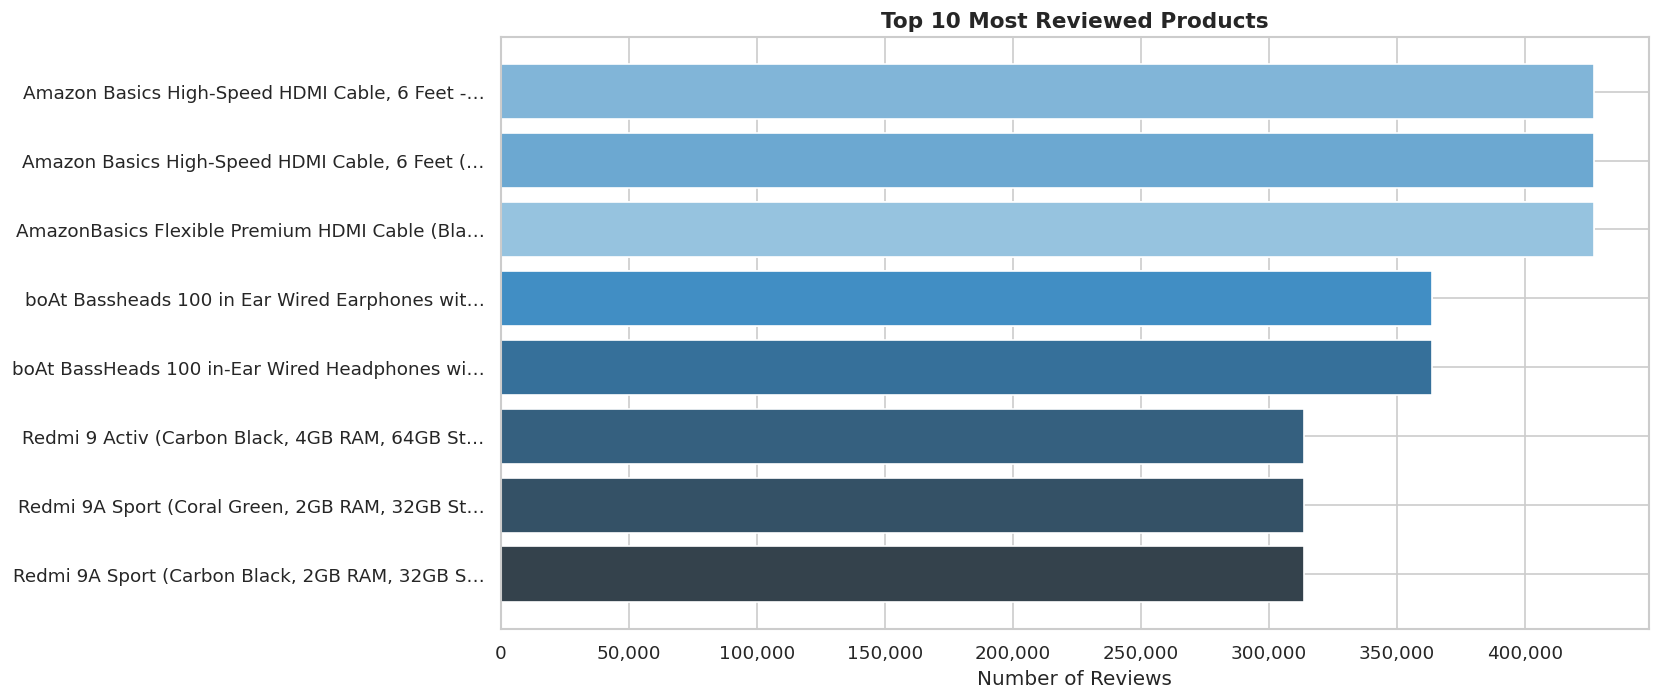

In [18]:
# Top 10 most reviewed products
top_reviewed = df.nlargest(10, 'rating_count_clean')[['product_name', 'main_category', 'rating', 'rating_count_clean']].reset_index(drop=True)
top_reviewed['product_name'] = top_reviewed['product_name'].apply(truncate)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top_reviewed['product_name'][::-1], top_reviewed['rating_count_clean'][::-1],
               color=sns.color_palette('Blues_d', 10)[::-1])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_title('Top 10 Most Reviewed Products', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Reviews')
plt.tight_layout()
plt.show()

## 9. Review Sentiment

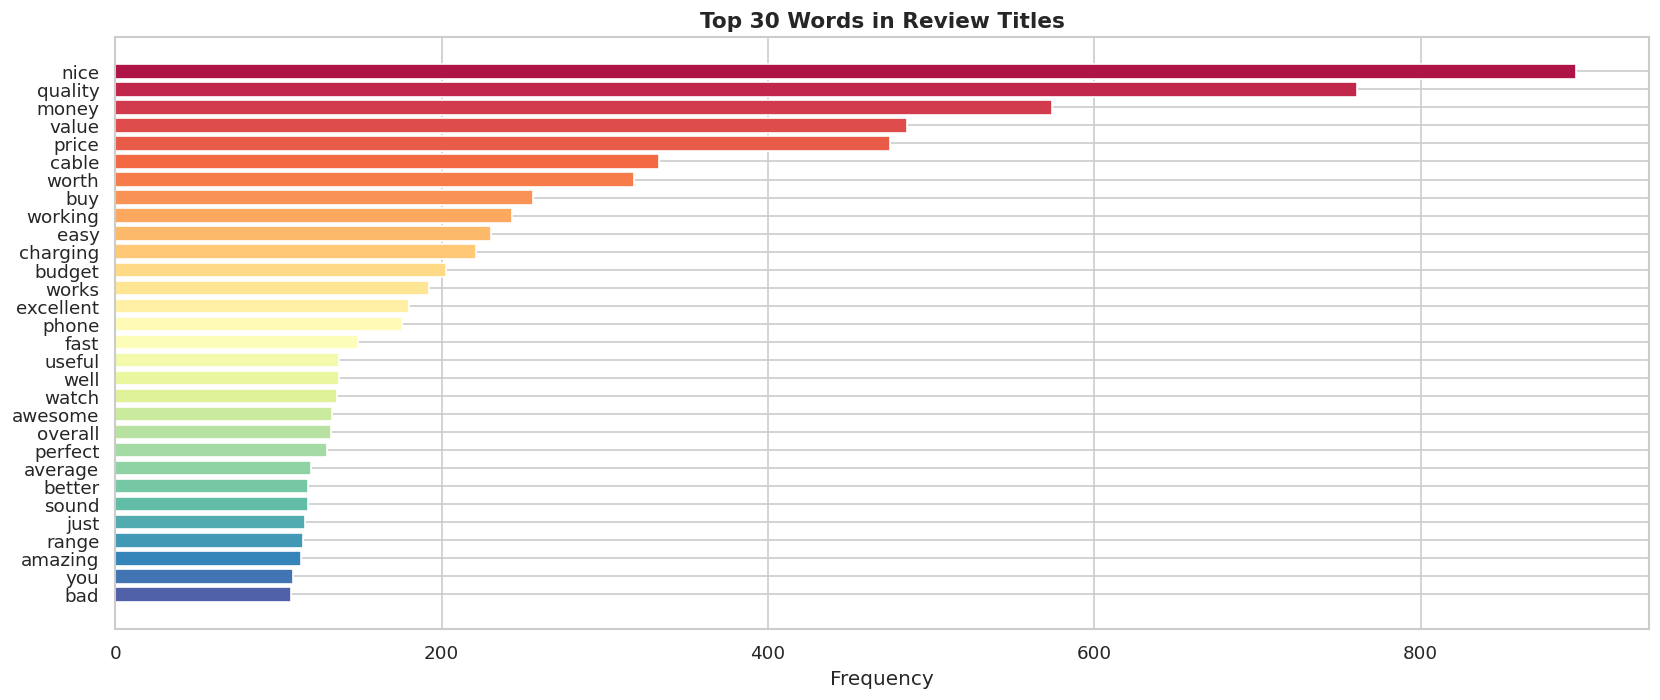

In [ ]:
# Word frequency from review titles
import re
from collections import Counter

STOPWORDS = {
    'the','a','an','is','it','in','on','at','of','and','to','for','with',
    'this','that','was','are','be','as','by','its','i','my','so','no',
    'but','if','or','from','very','great','good','best','product','item',
    'one','not','have','has','use','get','can','will','am','than','more'
}

all_words = []
for title in df['review_title'].dropna():
    words = re.findall(r'[a-z]+', title.lower())
    all_words.extend([w for w in words if w not in STOPWORDS and len(w) > 2])

word_freq = Counter(all_words).most_common(30)
words_df = pd.DataFrame(word_freq, columns=['word', 'count'])

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('Spectral', len(words_df))
ax.barh(words_df['word'][::-1], words_df['count'][::-1], color=colors[::-1])
ax.set_title('Top 30 Words in Review Titles', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

## 10. Price Range Segmentation

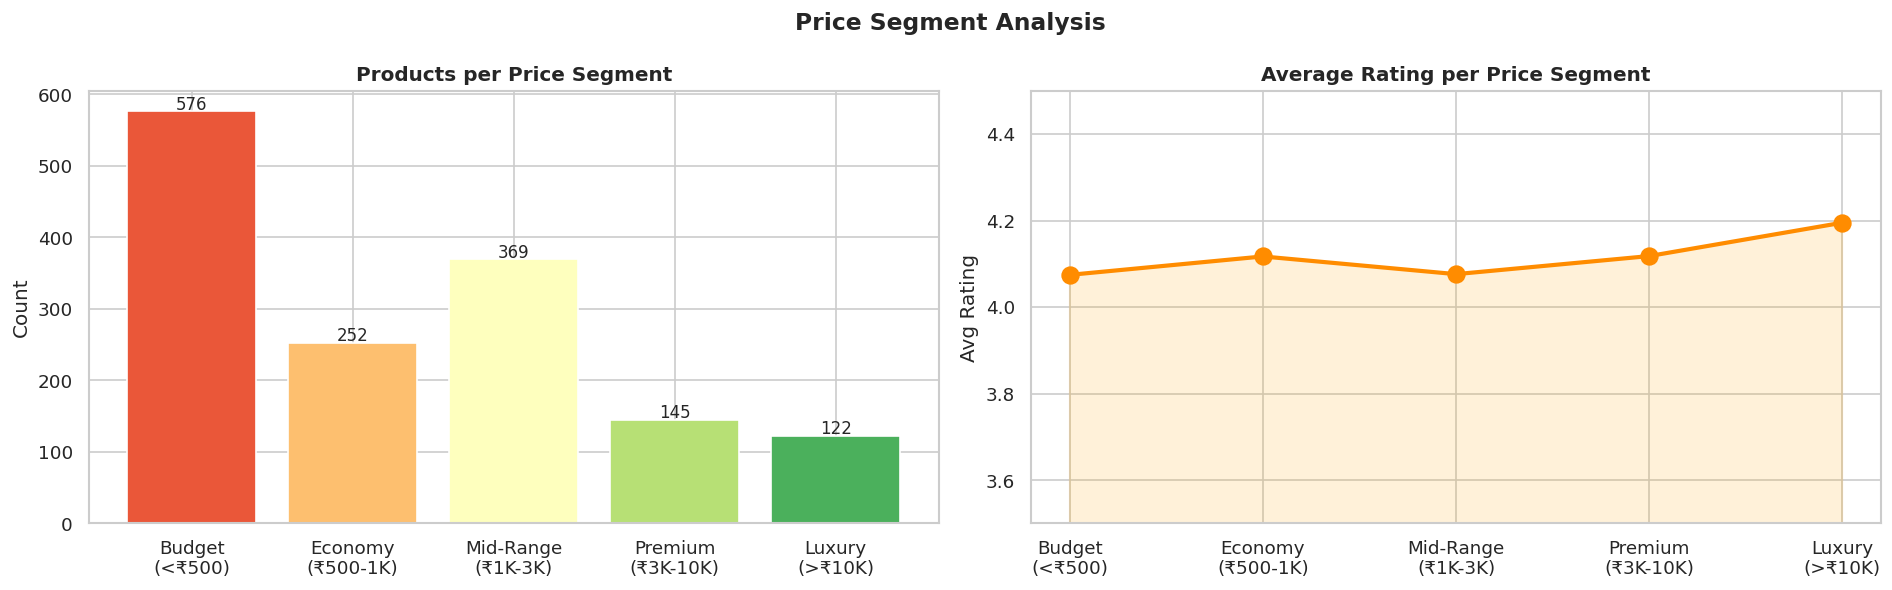

In [20]:
# Price segments
df['price_segment'] = pd.cut(
    df['discounted_price'],
    bins=[0, 500, 1000, 3000, 10000, np.inf],
    labels=['Budget\n(<₹500)', 'Economy\n(₹500-1K)', 'Mid-Range\n(₹1K-3K)', 'Premium\n(₹3K-10K)', 'Luxury\n(>₹10K)']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count per segment
seg_counts = df['price_segment'].value_counts().sort_index()
axes[0].bar(seg_counts.index, seg_counts.values,
            color=sns.color_palette('RdYlGn', len(seg_counts)), edgecolor='white')
axes[0].set_title('Products per Price Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=10)

# Avg rating per segment
seg_rating = df.groupby('price_segment', observed=True)['rating'].mean()
axes[1].plot(range(len(seg_rating)), seg_rating.values,
             marker='o', color='darkorange', linewidth=2.5, markersize=10)
axes[1].fill_between(range(len(seg_rating)), seg_rating.values, alpha=0.15, color='orange')
axes[1].set_xticks(range(len(seg_rating)))
axes[1].set_xticklabels(seg_rating.index)
axes[1].set_ylim(3.5, 4.5)
axes[1].set_title('Average Rating per Price Segment', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Rating')

plt.suptitle('Price Segment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Final Summary

In [21]:
print('=' * 60)
print('        AMAZON PRODUCTS — EDA SUMMARY')
print('=' * 60)
print(f"  Total products analyzed     : {len(df):,}")
print(f"  Unique categories           : {df['main_category'].nunique()}")
print(f"  Avg actual price            : ₹{df['actual_price'].mean():,.0f}")
print(f"  Avg discounted price        : ₹{df['discounted_price'].mean():,.0f}")
print(f"  Avg discount                : {df['discount_pct'].mean():.1f}%")
print(f"  Avg savings                 : ₹{df['savings'].mean():,.0f}")
print(f"  Avg rating                  : {df['rating'].mean():.2f} / 5")
print(f"  Most common category        : {df['main_category'].value_counts().idxmax()}")
print(f"  Most discounted category    : {df.groupby('main_category')['discount_pct'].mean().idxmax()}")
print(f"  Highest rated category      : {df.groupby('main_category')['rating'].mean().idxmax()}")
print('=' * 60)

        AMAZON PRODUCTS — EDA SUMMARY
  Total products analyzed     : 1,464
  Unique categories           : 9
  Avg actual price            : ₹5,447
  Avg discounted price        : ₹3,126
  Avg discount                : 47.7%
  Avg savings                 : ₹2,321
  Avg rating                  : 4.10 / 5
  Most common category        : Electronics
  Most discounted category    : HomeImprovement
  Highest rated category      : OfficeProducts


## 12. Save Cleaned Dataset

In [ ]:
cols_to_save = [
    'product_id', 'product_name', 'category', 'main_category', 'sub_category',
    'actual_price', 'discounted_price', 'discount_pct', 'savings',
    'rating', 'rating_count_clean', 'value_score',
    'about_product', 'user_id', 'user_name', 'review_id',
    'review_title', 'review_content', 'img_link', 'product_link',
    'price_segment'
]

save_cols = [c for c in cols_to_save if c in df.columns]
df_clean = df[save_cols].copy()

output_path = 'amazon_clean.csv'
df_clean.to_csv(output_path, index=False)

print(f'✅ Cleaned dataset saved to: {output_path}')
print(f'   Rows    : {len(df_clean):,}')
print(f'   Columns : {len(df_clean.columns)}')
print(f'   Columns : {df_clean.columns.tolist()}')
df_clean.head(3)

✅ Cleaned dataset saved to: amazon_clean.csv
   Rows    : 1,464
   Columns : 21
   Columns : ['product_id', 'product_name', 'category', 'main_category', 'sub_category', 'actual_price', 'discounted_price', 'discount_pct', 'savings', 'rating', 'rating_count_clean', 'value_score', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link', 'price_segment']


,product_id,product_name,category,main_category,sub_category,actual_price,discounted_price,discount_pct,savings,rating,...,value_score,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,price_segment
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories,Accessories&Peripherals,1099.0,399.0,64,700.0,4.2,...,42.407384,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Budget\n(<₹500)
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories,Accessories&Peripherals,349.0,199.0,43,150.0,4.0,...,42.767325,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Budget\n(<₹500)
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories,Accessories&Peripherals,1899.0,199.0,90,1700.0,3.9,...,35.015301,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Budget\n(<₹500)
